<a href="https://colab.research.google.com/github/melypadillareyes15-cell/Assignments-IA/blob/main/PIA_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Final Project**: *Classification of Pneumonia by Chest X-ray Images using a Convolutional Neural Network model (CNN).*
---

*   Melissa Montserrat Padilla Reyes 2043294
*   Diego Azael Lopez Chaires 2043064
*   Guillermo Eduardo Ponce de Leon Garza 2057925.

#**ABSTRACT**

This study presents the development and evaluation of a Convolutional Neural Network (CNN) trained based on medical imaging dataset to classify clinical conditions from X-rays. The dataset was divided into training and testing subsets to ensure a reliable assessment of the model’s generalization capability. The CNN architecture was implemented and optimized in a cloud-based environment, where model performance was monitored throughout the learning process. Training behavior was analyzed by examining accuracy trends across training and validation sets, providing insight into convergence and potential overfitting. The results highlight the effectiveness of deep learning methods for medical image analysis and contribute a structured dataset and reproducible workflow for future research in automated diagnostic support.


#**INTRODUCTION**

###What is Pneumonia?
Pneumonia is an inflammatory condition of the lung affecting primarily the small air sacs known as alveoli. Symptoms typically include some combination of productive or dry cough, chest pain, fever and difficulty breathing. The severity of the condition is variable. Pneumonia is usually caused by infection with viruses or bacteria and less commonly by other microorganisms, certain medications or conditions such as autoimmune diseases. Risk factors include cystic fibrosis, chronic obstructive pulmonary disease (COPD), asthma, diabetes, heart failure, a history of smoking, a poor ability to cough such as following a stroke and a weak immune system. Diagnosis is often based on symptoms and physical examination. Chest X-ray, blood tests, and culture of the sputum may help confirm the diagnosis. The disease may be classified by where it was acquired, such as community or hospital-acquired or healthcare-associated pneumonia.

Pneumonia is difficult to diagnose, according to a GE Healthcare report. Numerous pathogens, such as bacteria, fungi, and viruses, can cause pneumonia almost anyplace.  Pneumonia can be confused with other illnesses even when X-ray scans of patients' lungs are used, and it can be challenging to identify the infection's initial origin.  When the patient is dealing with other health issues, the confusion is even worse.  However, because pneumonia is deadly and severe, accurate diagnosis is crucial for patients.

###Convolutional Neural Networks to Diagnose Pneumonia

The use of artificial intelligence (AI) as a diagnostic assistance model in image-based medical specialties like radiology and pathology has been the subject of an increasing number of studies in recent years.  Because of their high accuracy rates, artificial neural networks have emerged as the most popular models among AI subfields for picture classification.

By extracting and comparing particular elements from images, a deep artificial neural network called a convolutional neural network (CNN) may identify and categorize them.  However, CNNs' primary drawback is that they require big training datasets.  A CNN that has been trained on a sizable dataset can be used to distinguish between similar images. Six  The acquisition of radiographic data has advanced significantly in recent years due to the widespread use of digital radiography and Picture Archiving and Communication Systems (PACS).  CT and magnetic resonance imaging offer multi-sectional and three-dimensional imaging, while radiography only offers single-section and two-dimensional imaging.  Consequently, simpler deep learning models can be used to process radiographs.


#**METHODOLOGY**

### ***1. Import libraries***

First we import these libraries that support the elaboration of the convolutional neural network for medical image classification. The **os** module allows interaction with the operating system, enabling navigation and file handling. **Numpy** provides all the numerical  operations and array manipulations which are essential for handling image data. **Matplotlib.pyplot** is used for visualizing images, training curves and to make prediction results. We also use *TensorFlow* and its **Keras API** to supply the deep learning framework used to train and evaluate the CNN  with datasets, layers and models; providing tools for architecture definition. Also, for enabling real time data augmentation we import **ImageDataGenerator** to improve the  model. The train_test_split function is used to partition the dataset into training and testing sets in a controlled and reproducible manner. Finally, kagglehub is used to automatically download datasets hosted on Kaggle.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split

import kagglehub

### ***2. Load dataset***

Then we download the dataset identified as **"paultimothymooney/chest-xray-pneumonia"**. The function **dataset_download()** handles the entire process of connecting to Kaggle, retrieving the files  and storing them in a local directory on the Colab environment. The returned value, saved in the variable path, contains the exact file path where the dataset was downloaded and the print statement displays it, allowing us to know where the images are located.


In [ ]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In this we are simply pointing to the folders where the images are already stored . The dataset already comes organized with a *train folder* and a *test folder*.

In [ ]:
DATASET_BASE = "/kaggle/input/chest-xray-pneumonia/chest_xray"
DATA_TRAIN = os.path.join(DATASET_BASE, "train")
DATA_TEST  = os.path.join(DATASET_BASE, "test")

### ***3. Preprocessing***

In this part of the code, what we did was define the two classes we are working with: “NORMAL” and “PNEUMONIA”. Then we created a function called **create_data**, which we used to load and prepare all the images from the dataset. Inside this function, we first check the folder we give it, and we list the two class folders inside it. For each class folder, we go through all the image files it contains. For every image, we read it with OpenCV then convert it to RGB so the colors look correct, and resize it to ***150 × 150*** pixels so all images have the same size. After that, we add the processed image to our images list, and we also add the correct label based on whether the image belongs to the NORMAL or PNEUMONIA folder. If any image cannot be read, we print an error message. This function is what we use to prepare all the images and labels **before training the model**.

In [ ]:
class_names = ["NORMAL", "PNEUMONIA"] # ["0", "1"]

# Image edition
def create_data(subset_path, images, labels):
    classes = sorted(os.listdir(subset_path))

    for class_name in classes:
        class_dir = os.path.join(subset_path, class_name)
        if not os.path.isdir(class_dir):
            continue

        image_list = glob.glob(os.path.join(class_dir, '*'))
        for img_path in image_list:
            try:
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (150, 150))
                images.append(image)
                label = class_names.index(class_name.upper())
                labels.append(label)
            except:
                print(f"Error leyendo {img_path}")

In this part, what we did was start by **creating two empty lists** called images and labels. These are the containers where we are going to store all the processed images and their corresponding class labels. After that, we used the function create_data, which we defined earlier, and we called it twice: once for the training folder (DATA_TRAIN) and once for the testing folder (DATA_TEST). Each time we call this function, it reads and processes the images and fills our images and labels lists. Once all the images and labels have been loaded and processed, we convert both lists into NumPy arrays** using np.array()**. We do this because NumPy arrays are the format that machine learning models need in order to train properly. So basically, in this section we initialized our lists, used the **create_data** function to fill them, and finally transformed everything into arrays ready for training.


In [ ]:
images = []
labels = []

# Using "create_data" to make the data for train and test
create_data(DATA_TRAIN, images, labels)
create_data(DATA_TEST, images, labels)

images = np.array(images)
labels = np.array(labels)

Now what we did was split our full dataset of images and labels into training and testing sets using the function train_test_split. We used **80%** of the data for training and **20% **for testing by setting **test_size=0.2**. The **random_state=42 **makes the split always the same each time we run the code, which helps keep the results consistent. After splitting the data, we **normalized** the images by **dividing every pixel value by 255.0.** This converts the pixel range from **0-255 to 0-1**, which helps the neural network train more efficiently. So here, we prepared the data by splitting it correctly and normalizing it so the model can learn better.


In [ ]:
# Split the dataset
train_images, test_images, train_labels, test_labels = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Normalization
train_images = train_images / 255.0
test_images = test_images / 255.0

In this part, what we did was print some information to check that our dataset was correctly loaded and split. First, we printed the total number of images we used in the whole project, both training and testing combined. Then, we printed how many images ended up in the training set and also showed the shape of train_images. The shape usually looks something like (number_of_images, 150, 150, 3), and the 3 at the end means that each image has three channels: Red, Green, and Blue (RGB). After that, we printed how many images were used for testing and the shape of test_images, which follows the same format. Basically, this section helps us confirm that the data is correctly organized and that the images have the right size and color channels.

In [ ]:
print("Total images of the dataset used for training and testing:", len(images))

print("\nTotal images of the dataset used for training:", len(train_labels))
print(train_images.shape)
print("Total images of the dataset used for testing:", len(test_labels))
print(test_images.shape)


Total images of the dataset used for training and testing: 5840

Total images of the dataset used for training: 4672
(4672, 150, 150, 3)
Total images of the dataset used for testing: 1168
(1168, 150, 150, 3)


### ***4. Structure and training of Convolutional Artificial Neural Network (CNN)***

In this part, what we did was create our Convolutional Neural Network using **models.Sequential()**. Inside the model, we first added the convolutional layers, which are the ones that learn to detect features such as edges, textures, and shapes from the images. Each convolutional layer is followed by a MaxPooling2D layer, which **reduces the size of the feature maps** and helps the model generalize better. We used three convolutional blocks with **32, 64, and 128 filters**. The input shape ***(150, 150, 3) ***tells the model that our images are 150×150 pixels with three RGB channels. After this feature extraction stage, we flattened the output and added two Dense layers for learning and classification. The last Dense layer uses softmax, meaning it outputs probabilities for each class.

In [ ]:
model = models.Sequential([
    # Convolutional part
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    # Learning part
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation = 'softmax')
])

Next, we compiled the model by choosing the elements it needs to learn properly. We used the Adam optimizer, which helps adjust the model’s weights efficiently during training. For the loss function, we used **sparse_categorical_crossentropy**, which is the correct choice because our labels are integers. Finally, we told the model to track accuracy, so we can see how well it performs during training.

In [ ]:
# Model Complilation: Features
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Finally, we trained the model **using model.fit()**. Here, we passed the training images and labels, and we chose to train for **5 epoch**s, meaning the model goes through the entire dataset **five times**. We selected this number of epochs because the dataset was quite large, and using more epochs would significantly **increase the training time without offering a clear advantage**. We also included **validation_data** using the test images and labels so that after each epoch, we can see how well the model performs on data it has never seen. During training, we can see both the accuracy and loss for the training set and the validation set. This helps us understand whether the model is learning correctly or overfitting. In our results, the accuracy kept increasing and the validation accuracy was also high, showing that the model was training effectively.

In [ ]:
# CNN training and creation of validation data
CNNmodel = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

Epoch 1/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.9564 - loss: 0.1070 - val_accuracy: 0.9426 - val_loss: 0.1413
Epoch 2/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.9691 - loss: 0.0800 - val_accuracy: 0.9443 - val_loss: 0.1375
Epoch 3/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9803 - loss: 0.0579 - val_accuracy: 0.9469 - val_loss: 0.1463
Epoch 4/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.9802 - loss: 0.0500 - val_accuracy: 0.9409 - val_loss: 0.2203
Epoch 5/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9872 - loss: 0.0350 - val_accuracy: 0.9503 - val_loss: 0.1737


### ***5. Plot of training accuracy vs validation accuracy during the training of the CNN.***

In this part, what we did was create a plot to compare the training accuracy and validation accuracy across all the epochs. First, we opened a figure with a specific size using **plt.figure(figsize=(8,5))**. Then we created a variable called epochs, which simply counts the number of epochs we trained the model for. After that, we plotted the training accuracy by taking the values stored in **CNNmodel.history['accuracy']** and we decided the color of the markers to make the points easy to see. We also plotted the validation accuracy using the values in **CNNmodel.history['val_accuracy']** with a light blue color. By adding a title, labels for the axes, and a legend, we made the graph easy to understand. Finally, we displayed the plot using **plt.show()**. This graph helps us see how well the model learned during training and how well it performed on unseen data during validation.


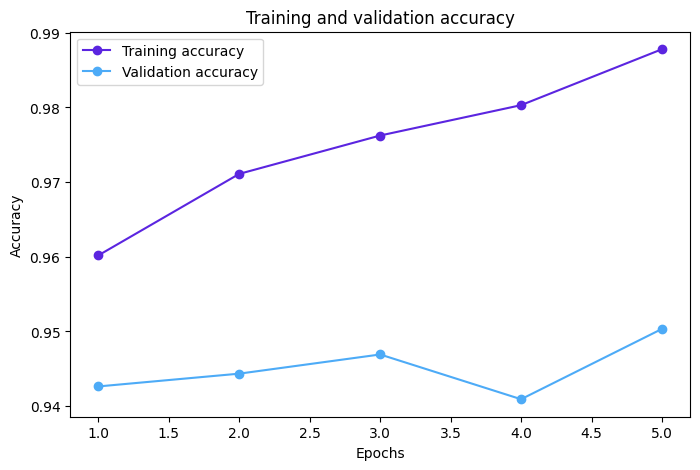

In [ ]:
# Plot with the difference in accuracy values from training and validation.

plt.figure(figsize=(8,5))

epochs = range(1, len(CNNmodel.history['accuracy']) + 1)

plt.plot(epochs, CNNmodel.history['accuracy'],
         color='#5b25e0', marker='o', label='Training accuracy')

plt.plot(epochs, CNNmodel.history['val_accuracy'],
         color='#4dabf7', marker='o', label='Validation accuracy')

plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


### ***6. Predictions***

Finally for the predictions, we generate and display**10 predictions** from our trained model using images from the test set. First, we selected the first **10 images** from the testing dataset along with their true labels. Then, we used the model to make predictions on these images, and we converted the prediction probabilities into class numbers using **np.argmax**. After that, we created a small dictionary to map the numeric labels to readable class names, like ***“Normal”*** and ***“Pneumonia.”*** We transformed both the true labels and the predicted labels into their corresponding text values so the results would be easier to understand. Finally, we created a 2x5 grid of images with Matplotlib, showing each test image along with its predicted label (**P**) and its true label (**T**) under it. This visualization helps us quickly check how well the model is performing on real test samples.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


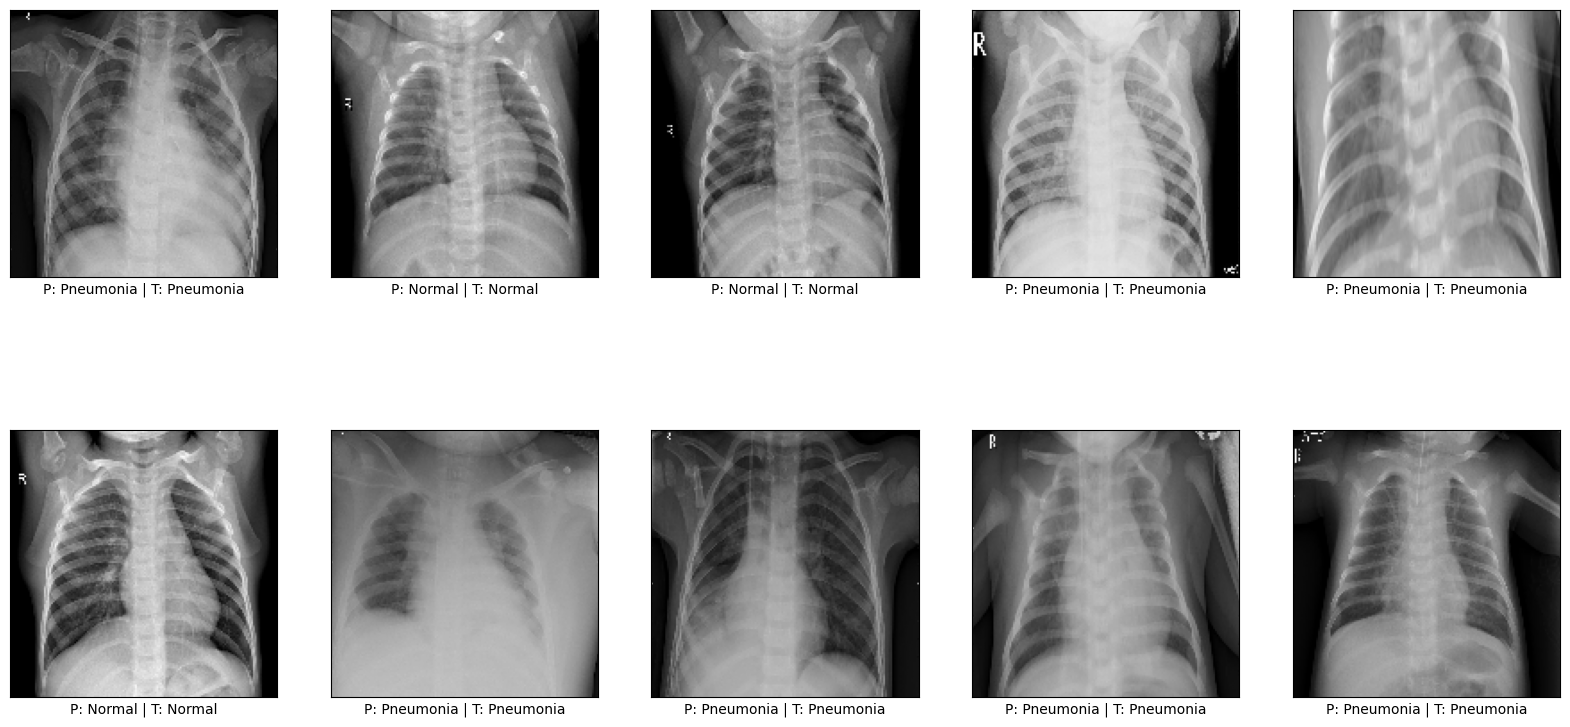

In [ ]:


num_images = 10

test_subset = test_images[:num_images]
true_labels = test_labels[:num_images]


predictions = model.predict(test_subset)
predicted_classes = np.argmax(predictions, axis=1)


label_map = {
    0: 'Normal',
    1: 'Pneumonia'
}

true_labels_str = [label_map[label] for label in true_labels]
predicted_labels_str = [label_map[p] for p in predicted_classes]

plt.figure(figsize=(20, 10))

for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(test_subset[i])

    plt.xlabel(f"P: {predicted_labels_str[i]} | T: {true_labels_str[i]}")

plt.show()


#**RESULTS**

Our model, showed a high accuracy since the very first epoch and it continued
to increase throughout the whole training and only decrease a little in the validation but it continued to increase on the next epoch.

| Metric          | Final Value |
|-----------------|-------------|
| Training Acc    | 98.72%      |
| Training Loss   | 0.035       |
| Validation Acc  | 95.03%      |
| Validation Loss | 0.1737      |

We attribute these great results, even though we chose to use just 5 epochs, to the amount of data selected to train our CNN (5and the resolution of the images. Throughout the development process of this CNN, we pondered these different factors and chose to not sacrifice the amount of data over the number of epochs, and our results showed this to be the right decision.

#**DISCUSSION AND CONCLUSION**

Using the Chest X-Ray Images dataset, this project effectively constructed a Convolutional Neural Network that can correctly classify chest X-ray images into pneumonia and normal categories.  The model performed well from the very beginning of training, demonstrating the caliber of the dataset as well as the efficiency of CNNs for medical picture interpretation.  The project's continuously excellent accuracy suggests the viability of using deep learning-based techniques as an additional screening tool for pneumonia.

One noteworthy conclusion is that the model needed very little architectural complexity to produce accurate results, indicating that even lightweight CNNs are capable of successfully extracting the diagnostic features found in pediatric chest X-ray pictures.  This highlights the possibility of creating quick, easily accessible, and effective AI-assisted diagnostic tools, especially for healthcare settings with low resources.

Expanding the dataset with photos from various patient groups, implementing strategies to boost generalization even further, and experimenting with more sophisticated architectures or explainability techniques like Grad-CAM are some potential future enhancements.  These actions could improve the model's resilience and move it closer to practical clinical application.

#**REFERENCES**



* Ai, I. (2023, March 6). Diagnosis of Pneumonia with the use of AI — Inspirit AI. Inspirit AI. https://www.inspiritai.com/blogs/ai-student-blog/diagnosis-of-pneumonia-with-the-use-of-ai
* Ayaz, E., Güçlü, H., & Oktay, A. B. (2025). Diagnostic accuracy of convolutional neural network algorithms to distinguish Gastrointestinal obstruction on conventional radiographs in a pediatric population. Diagn. Interv. Radiol  
* Mooney, P. (2018, March 24). Chest X-Ray images (Pneumonia). https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


